In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style='whitegrid')
df = pd.read_csv('Mall_Customers.csv')
df.rename(columns={'Genre': 'Gender'}, inplace=True)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.isnull().sum()
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

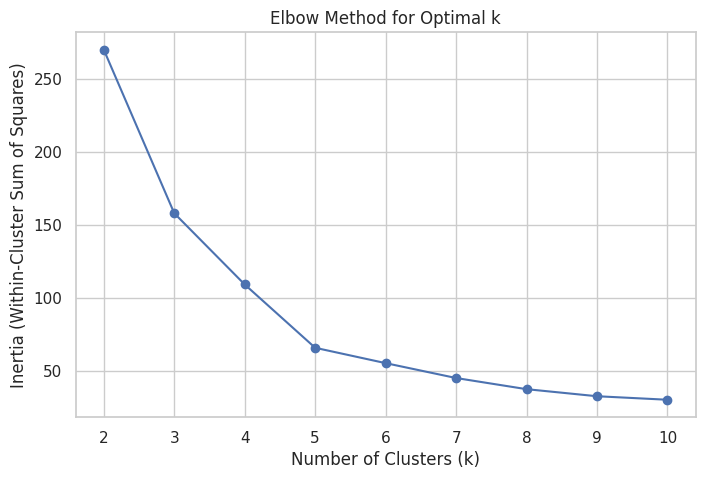

In [4]:
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.show()

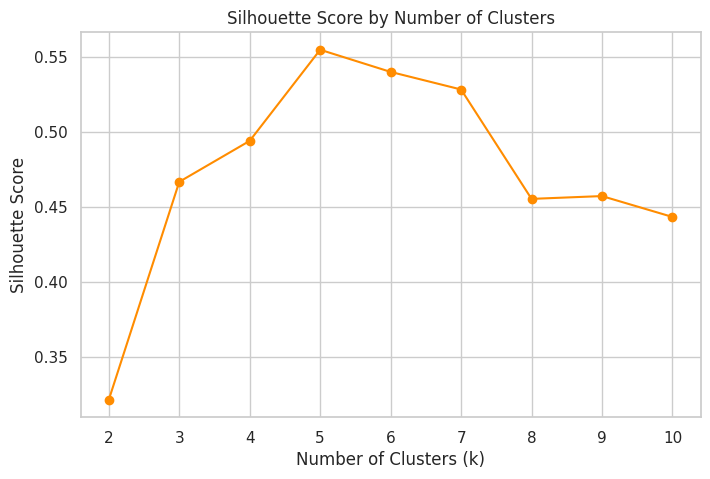

In [5]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker='o', color='darkorange')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score (k=5):', silhouette_score(X_scaled, df['Cluster']))
print(df['Cluster'].value_counts().sort_index())

Silhouette Score (k=5): 0.5546571631111091
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


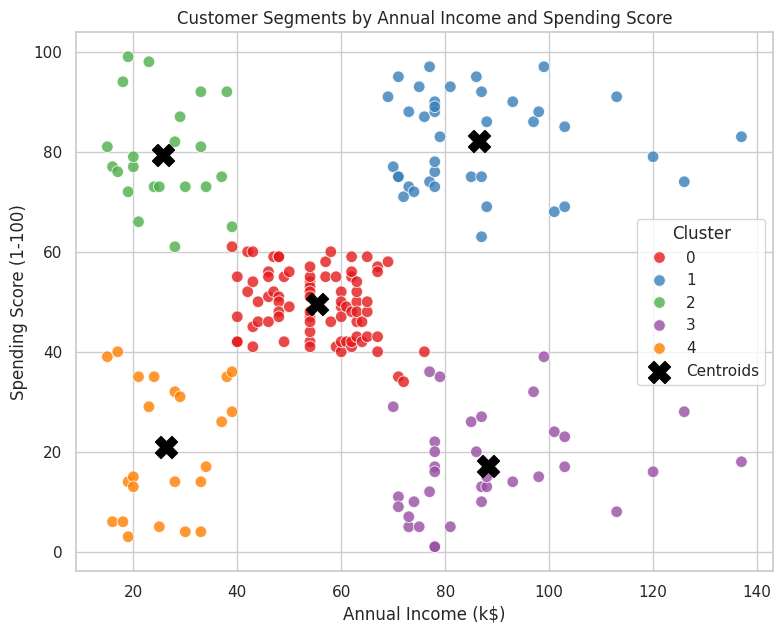

In [7]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

plt.figure(figsize=(9, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df, palette='Set1', s=70, alpha=0.8)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            s=250, c='black', marker='X', label='Centroids')
plt.title('Customer Segments by Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

In [8]:
profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean'),
).round(1)
print(profile)
print(pd.crosstab(df['Cluster'], df['Gender']))

         Count  Avg_Age  Avg_Income  Avg_Spending
Cluster                                          
0           81     42.7        55.3          49.5
1           39     32.7        86.5          82.1
2           22     25.3        25.7          79.4
3           35     41.1        88.2          17.1
4           23     45.2        26.3          20.9
Gender   Female  Male
Cluster              
0            48    33
1            21    18
2            13     9
3            16    19
4            14     9


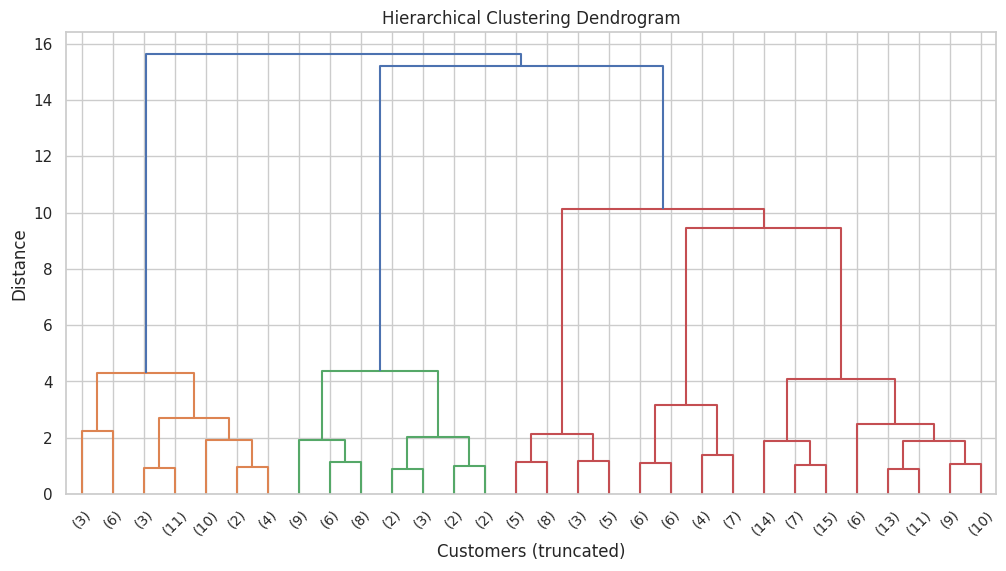

Silhouette Score (Hierarchical): 0.5538089226688662
Cluster_H   0   1   2   3   4
Cluster                      
0           0   0  81   0   0
1           0  39   0   0   0
2           0   0   1  21   0
3          32   0   3   0   0
4           0   0   0   0  23


In [9]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers (truncated)')
plt.ylabel('Distance')
plt.show()

agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Cluster_H'] = agg.fit_predict(X_scaled)

print('Silhouette Score (Hierarchical):', silhouette_score(X_scaled, df['Cluster_H']))
print(pd.crosstab(df['Cluster'], df['Cluster_H']))


In [10]:
df.to_csv('mall_customers_clustered.csv', index=False)